In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from scipy.stats import multivariate_normal
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from vae.models import GaussVAE
from vae.trainers import GaussVAETrainer
from vae.neural_networks import EncoderGaussVAE, DecoderGaussVAE
from pathlib import Path

# Data

## Unit circle

In [2]:
class CircleDataset(Dataset):

    def __init__(self, size: int=1000, sigma: float=0.05) -> None:
        self.size = size
        self.sigma = sigma
        self.X = self.reset()

    def reset(self) -> np.ndarray:
        """
        Generate the data.
        """
        
        normal = multivariate_normal([0, 0], np.eye(2))
        e = normal.rvs(self.size)
        theta = np.random.uniform(0, 2*np.pi, self.size)
        x = np.cos(theta) + self.sigma*e[:, 0]
        y = np.sin(theta) + self.sigma*e[:, 1]
        return np.vstack((x, y), dtype=np.float32).T

    def plot(self, fig_size: tuple[int, int]=(6, 6)) -> None:
        """
        Plot the generated data points.
        """

        fig, ax = plt.subplots(1, 1, figsize=fig_size)
        ax.scatter(self.X[:, 0], self.X[:, 1], s=1)
        ax.grid()
        ax.set_facecolor("lightgrey")
        plt.show()

    def __len__(self) -> int:
        return self.size

    def __getitem__(self, index: int) -> np.ndarray:
        return self.X[index]

In [3]:
size = 10000
sigma = 0.05

dataset = CircleDataset(size, sigma)

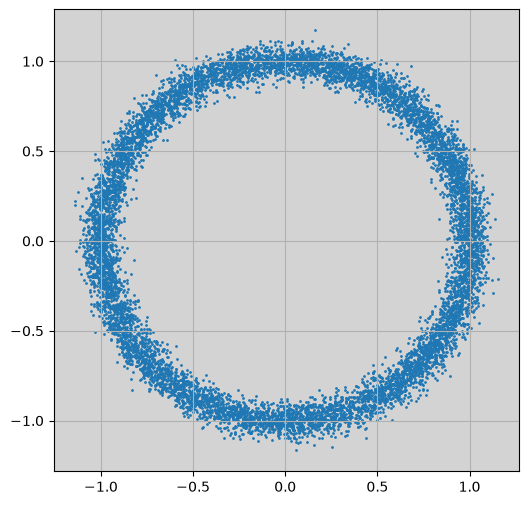

In [4]:
dataset.plot()

# Model

In [5]:
data_dim = 2
latent_dim = 2

encoder = EncoderGaussVAE(data_dim, latent_dim)
decoder = DecoderGaussVAE(data_dim, latent_dim)
encoder_decoder = nn.ModuleDict({
    "encoder" : encoder, 
    "decoder" : decoder
})

In [6]:
sigma = 0.05
model = GaussVAE(encoder, decoder, sigma)

# Training

In [7]:
batch_size = 8
lr = 1e-3

dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
optimizer = Adam(encoder_decoder.parameters(), lr=lr)
trainer = GaussVAETrainer(model, dataloader, optimizer)

In [8]:
n_epochs = 10
n_latent = 64
log_dir = Path("/Users/aymanchaouki/Documents/Personal/projects/generative-models/runs/")
n_log = 1

trainer.train(n_epochs, n_latent, log_dir, n_log)

# Evaluation

In [9]:
n_samples = 10000
X_sampled = model.sample(n_samples)

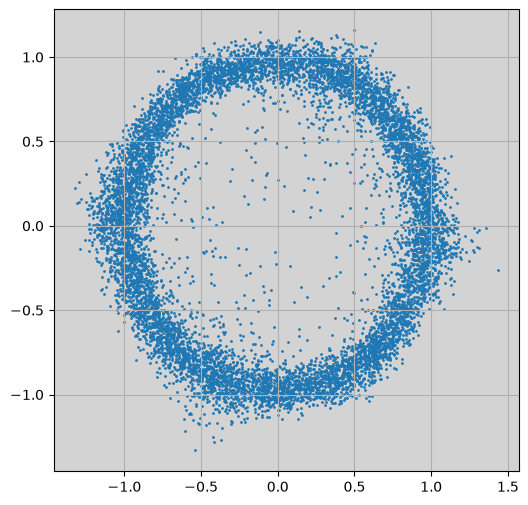

In [10]:
fig_size = (6, 6)
fig, ax = plt.subplots(1, 1, figsize=fig_size)
ax.scatter(X_sampled[:, 0], X_sampled[:, 1], s=1)
ax.grid()

ax.set_facecolor("lightgrey")
plt.show()